C:\Users\Haneen.Muhammad\AppData\Local\Temp\ipykernel_38396\1383157944.py:75: RuntimeWarning: invalid value encountered in log10
  elif x > 10**((np.log10(xlim[1]) + np.log10(xlim[0])) * 0.75):  # 75% of log range


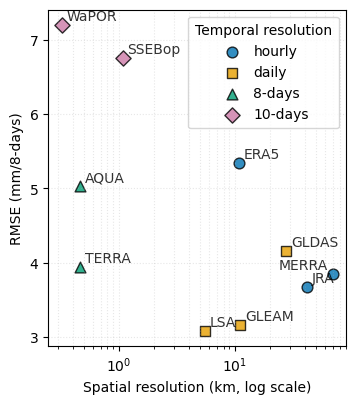

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import pearsonr

# Constants for conversion (1° ≈ 111 km at equator)
DEG_TO_KM = 111.32  

# Load data
STN_DATA = xr.open_dataarray("../DATA/STN_DATA.nc")
STN_RMSE = xr.open_dataarray("../DATA/STN_RMSE.nc")

# Calculate mean RMSE across stations
R_RMSEm = STN_RMSE.drop_sel(Product=["PM", "TH"]).mean(dim="Station")

# Product spatial and temporal resolutions
resolution_data = {
    'Product': ['MERRA', 'JRA', 'GLDAS', 'GLEAM', 'ERA5', 'LSA', 'SSEBop', 'AQUA', 'TERRA', 'WaPOR'],
    'Resolution_deg': [0.6250, 0.3750, 0.2500, 0.1000, 0.0981, 0.0500, 0.0097, 0.0042, 0.0042, 0.0029],
    'Resolution_km': [x*DEG_TO_KM for x in [0.6250, 0.3750, 0.2500, 0.1000, 0.0981, 
                                           0.0500, 0.0097, 0.0042, 0.0042, 0.0029]],
    'Temporal_Resolution': ['hourly', 'hourly', 'daily', 'daily', 'hourly', 
                           'daily', '10-days', '8-days', '8-days', '10-days']
}

# Create DataFrame
df = pd.DataFrame(resolution_data)
df['RMSE'] = R_RMSEm.values

# Create figure
plt.figure(figsize=(3.5, 4))  
plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'legend.title_fontsize': 10
})

# Define colors for different temporal resolutions
style_dict = {
    'hourly':  {'color': '#0072B2', 'marker': 'o'},  # blue, circle
    'daily':   {'color': '#E69F00', 'marker': 's'},  # orange, square
    '8-days':  {'color': '#009E73', 'marker': '^'},  # green, triangle
    '10-days': {'color': '#CC79A7', 'marker': 'D'}   # purple, diamond
}

# Plot RMSE vs Resolution (km) with different colors for temporal resolution
for temp_res, style in style_dict.items():
    subset = df[df['Temporal_Resolution'] == temp_res]
    plt.scatter(subset['Resolution_km'], subset['RMSE'],
                c=style['color'], s=60, edgecolor='k',
                marker=style['marker'], label=temp_res, alpha=0.8)


# Add product labels with intelligent positioning
ax = plt.gca()  # Get current axis
xlim = ax.get_xlim()  # Get current x-axis limits
ylim = ax.get_ylim()  # Get current y-axis limits

for i, row in df.iterrows():
    x, y = row['Resolution_km'], row['RMSE']
    
    # Default offset (right side)
    xytext = (3.5, 3.5)
    ha = 'left'
    
    # Special case for MERRA - place on left
    if row['Product'] == 'MERRA':
        xytext = (-3.5, 3.5)
        ha = 'right'
    # For other products near right edge, move left
    elif x > 10**((np.log10(xlim[1]) + np.log10(xlim[0])) * 0.75):  # 75% of log range
        xytext = (-3.5, 3.5)
        ha = 'right'
    
    plt.annotate(row['Product'], 
                (x, y),
                xytext=xytext,
                textcoords='offset points',
                fontsize=10,
                alpha=0.8,
                ha=ha)  # Set horizontal alignment

# [Rest of the code remains the same]

# Format plot
plt.xscale('log')
plt.xlabel('Spatial resolution (km, log scale)')
plt.ylabel('RMSE (mm/8-days)')
plt.grid(True, which="both", ls=":", alpha=0.3) 

# Adjust legend position and style
legend = plt.legend(title='Temporal resolution', 
                   frameon=True, 
                   framealpha=0.8,
                   loc='upper right',
                   borderpad=0.5,
                   handletextpad=0.5)

# Adjust layout and save
plt.tight_layout(pad=0.5)
plt.savefig("ET4I_Resolution.png", 
           dpi=600,
           bbox_inches='tight',
           transparent=True)
plt.show()